In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df=pd.read_csv("stock_data.csv")

In [23]:
df

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0
7,2026-01-13,109.53,111.44,107.88,NaN,69124.0
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0
9,2026-01-15,110.07,114.76,109.21,112.32,80764.0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    50 non-null     object 
 1   Open    49 non-null     float64
 2   High    49 non-null     float64
 3   Low     50 non-null     float64
 4   Close   49 non-null     float64
 5   Volume  49 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.5+ KB


In [25]:
df["Date"]=pd.to_datetime(df["Date"])
df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object

In [26]:
df.shape

(50, 6)

In [27]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0


In [28]:
df.tail()

,Date,Open,High,Low,Close,Volume
45,2026-03-06,90.39,91.24,86.89,87.76,97471.0
46,2026-03-09,89.76,92.53,87.80,90.65,66641.0
47,2026-02-06,98.04,100.96,97.53,99.98,72635.0
48,2026-03-11,92.68,95.36,90.84,92.99,72745.0
49,2026-03-12,89.71,90.49,88.09,89.54,95006.0


In [29]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,50,49.000000,49.000000,50.000000,49.000000,49.000000
mean,2026-02-04 11:02:24,99.691837,101.791837,97.747600,99.771837,109429.020408
min,2026-01-02 00:00:00,89.710000,90.490000,86.890000,87.760000,40190.000000
25%,2026-01-19 06:00:00,95.840000,97.070000,92.650000,94.820000,67643.000000
50%,2026-02-04 12:00:00,98.640000,101.260000,97.360000,99.980000,80447.000000
75%,2026-02-22 00:00:00,103.280000,106.280000,102.270000,105.210000,90132.000000
max,2026-03-12 00:00:00,110.070000,114.760000,109.210000,112.320000,850000.000000
std,NaN,5.688624,6.160336,5.879341,6.150594,143886.493209


In [30]:
df.isnull().sum()

Date      0
Open      1
High      1
Low       0
Close     1
Volume    1
dtype: int64

In [31]:
df['Close'] = df['Close'].ffill()


In [32]:
df['Open'] = df['Open'].bfill()


In [33]:
df['Volume'] = df['Volume'].ffill()


In [34]:
df['High'] = df['High'].ffill()

In [35]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [36]:
df=df.sort_values("Date")
df

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0
20,2026-01-09,104.91,108.22,103.42,107.07,81919.0
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0
7,2026-01-13,109.53,111.44,107.88,106.57,69124.0
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0


In [37]:
df["MA_5"]=df["Close"].rolling(5).mean()
df["MA_20"]=df["Close"].rolling(20).mean()
df

,Date,Open,High,Low,Close,Volume,MA_5,MA_20
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0,NaN,NaN
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0,NaN,NaN
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0,NaN,NaN
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0,NaN,NaN
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0,103.668,NaN
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0,104.674,NaN
20,2026-01-09,104.91,108.22,103.42,107.07,81919.0,105.972,NaN
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0,107.014,NaN
7,2026-01-13,109.53,111.44,107.88,106.57,69124.0,106.954,NaN
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0,107.426,NaN


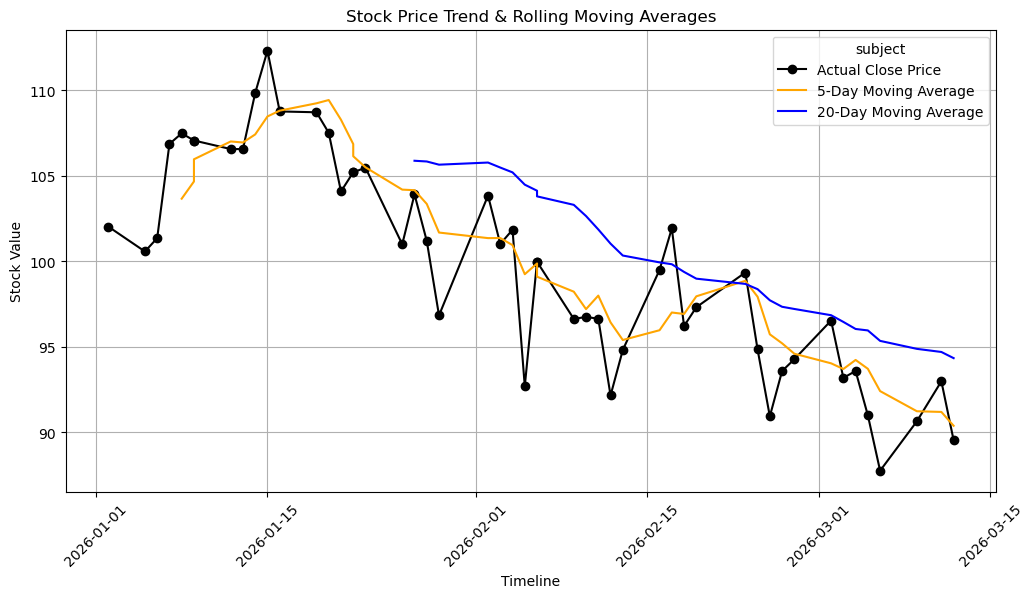

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label='Actual Close Price', color='black', marker='o')
plt.plot(df['Date'], df['MA_5'], label='5-Day Moving Average ', color='orange')
plt.plot(df['Date'], df['MA_20'], label='20-Day Moving Average', color='blue')

plt.title('Stock Price Trend & Rolling Moving Averages')
plt.xlabel('Timeline')
plt.ylabel('Stock Value')
plt.grid(True)
plt.legend(title="subject")
plt.xticks(rotation=45)
plt.show()